# *****Imports & Configurations*****

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
!pip install xgboost

## Data Collection:


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Internship projects/HealthCareAnalytics.csv")

## ****Domain Analysis:-****
- **case_id** → Unique ID for each patient case
- **Hospital_code** → Unique ID of hospital
- **Hospital_type_code** → Type/category of hospital
- **City_Code_Hospital** → City where hospital is located
- **Hospital_region_code** → Region of the hospital
- **Available_Extra_Rooms_in_Hospital** → Extra rooms available
- **Department** → Medical department (e.g., surgery, gynecology)
- **Ward_Type** → Type of ward (general, private, etc.)
- **Ward_Facility_Code** → Facility type in ward
- **Bed_Grade** → Quality level of bed
- **patientid** → Unique patient ID
- **City_Code_Patient** → Patient’s city
- **Type_of_Admission** → Emergency or planned admission
- **Severity_of_Illness** → Level of illness (mild/moderate/severe)
- **Visitors_with_Patient** → Number of visitors
- **Age** → Patient age group
- **Admission_Deposit** → Initial deposit amount
- **Stay** → Length of hospital stay (target variable)

## ******Basic Checks:-******

In [6]:

pd.reset_option('display.max_columns', None)


In [7]:

df.head()

,case_id,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility_Code,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay
0,1,8,c,3,Z,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,c,5,Z,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,e,1,X,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,b,2,Y,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,b,2,Y,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50


In [8]:
df.shape

(318438, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital_code                      318438 non-null  int64  
 2   Hospital_type_code                 318438 non-null  object 
 3   City_Code_Hospital                 318438 non-null  int64  
 4   Hospital_region_code               318438 non-null  object 
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility_Code                 318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  
 11  City_Code_Patient                  3139

#### ***Insights:-***
- Total Number of Row : 318438
- Total Number of features : 18
- Numerical features : 9
- Categorical Features : 9
- Helps detect missing values
- Gives memory usage of dataset

In [10]:
df.isnull().sum()

,0
case_id,0
Hospital_code,0
Hospital_type_code,0
City_Code_Hospital,0
Hospital_region_code,0
Available_Extra_Rooms_in_Hospital,0
Department,0
Ward_Type,0
Ward_Facility_Code,0
Bed_Grade,113


In [11]:
df.describe()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Visitors_with_Patient,Admission_Deposit
count,318438.000000,318438.000000,318438.000000,318438.000000,318325.000000,318438.000000,313906.000000,318438.000000,318438.000000
mean,159219.500000,18.318841,4.771717,3.197627,2.625807,65747.579472,7.251859,3.284099,4880.749392
std,91925.276847,8.633755,3.102535,1.168171,0.873146,37979.936440,4.745266,1.764061,1086.776254
min,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1800.000000
25%,79610.250000,11.000000,2.000000,2.000000,2.000000,32847.000000,4.000000,2.000000,4186.000000
50%,159219.500000,19.000000,5.000000,3.000000,3.000000,65724.500000,8.000000,3.000000,4741.000000
75%,238828.750000,26.000000,7.000000,4.000000,3.000000,98470.000000,8.000000,4.000000,5409.000000
max,318438.000000,32.000000,13.000000,24.000000,4.000000,131624.000000,38.000000,32.000000,11008.000000


### ****Insights:-****
- Provides statistical summary of numerical columns
- Shows mean, median (50%), min, max values
- Helps identify outliers
- Shows data spread using standard deviation
- Useful to check distribution of data (skewness idea from quartiles)

In [12]:
df.describe(include='O')

,Hospital_type_code,Hospital_region_code,Department,Ward_Type,Ward_Facility_Code,Type_of_Admission,Severity_of_Illness,Age,Stay
count,318438,318438,318438,318438,318438,318438,318438,318438,318438
unique,7,3,5,6,6,3,3,10,11
top,a,X,gynecology,R,F,Trauma,Moderate,41-50,21-30
freq,143425,133336,249486,127947,112753,152261,175843,63749,87491


### ****Insights:-****
- Shows count of non-null values for each categorical column
- Displays number of unique categories (unique)
- Identifies the most frequent category (top)
- Shows frequency of the top category (freq)
- Helps detect dominant categories (if freq is very high)
- Useful to find low-variance columns (few unique values)
- Can indicate imbalanced data in categorical features
- Helps identify possible data entry issues (unexpected categories)

# ********Exploratory Data Analysis:-********(EDA)

In [13]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print('numeric columns: \n', num_cols)
print('categorical columns: \n', cat_cols)

numeric columns: 
 Index(['case_id', 'Hospital_code', 'City_Code_Hospital',
       'Available_Extra_Rooms_in_Hospital', 'Bed_Grade', 'patientid',
       'City_Code_Patient', 'Visitors_with_Patient', 'Admission_Deposit'],
      dtype='object')
categorical columns: 
 Index(['Hospital_type_code', 'Hospital_region_code', 'Department', 'Ward_Type',
       'Ward_Facility_Code', 'Type_of_Admission', 'Severity_of_Illness', 'Age',
       'Stay'],
      dtype='object')


## *******Univariate Analysis*******

#### ****Numerical Columns:-**** Univariate Analysis

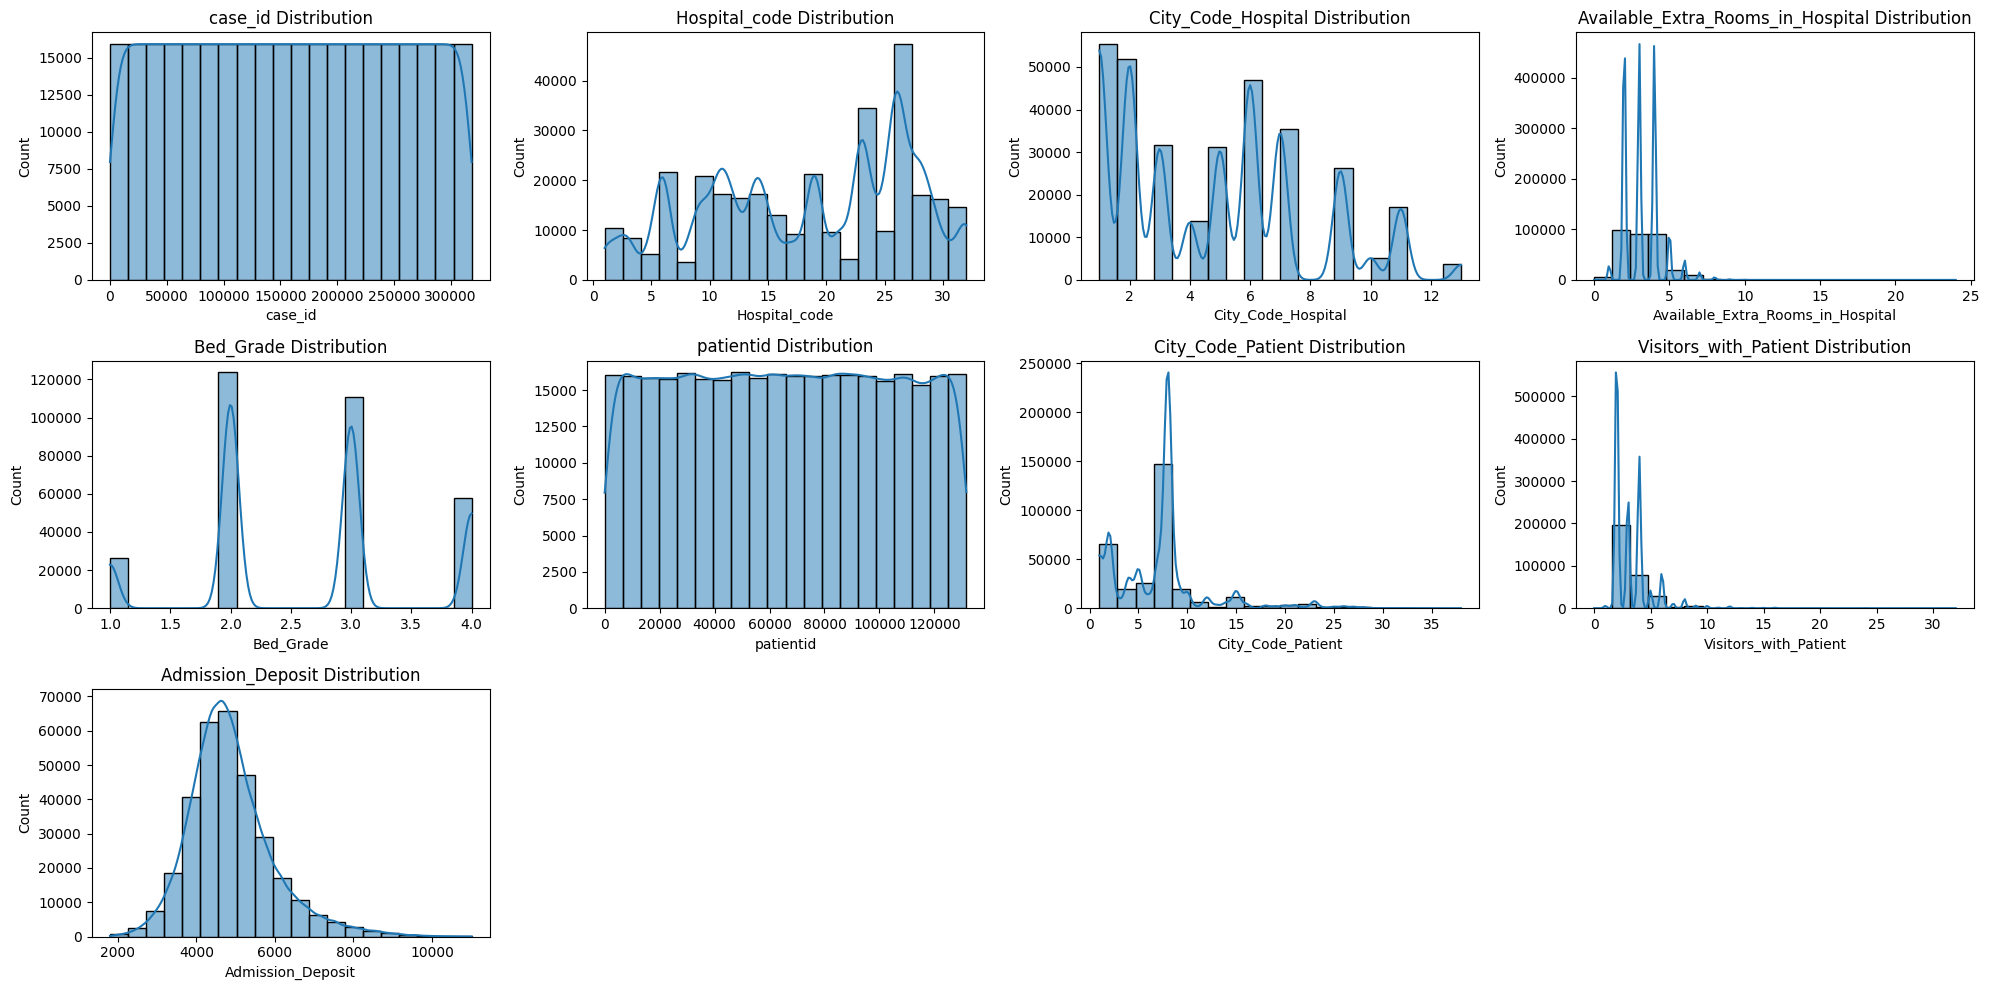

In [14]:
pltn = 1
plt.figure(figsize=(20,10))

for col in num_cols:
  plt.subplot(3,4,pltn)
  sns.histplot(df[col], kde=True, bins=20)
  plt.title(f"{col} Distribution")
  pltn += 1
plt.tight_layout()
plt.show()

### ***Insights:-***
- Visualizes the distribution of all numerical features, helping identify skewness, spread, and outliers.

#### ****Categorical Columns:-**** Univariate Analysis

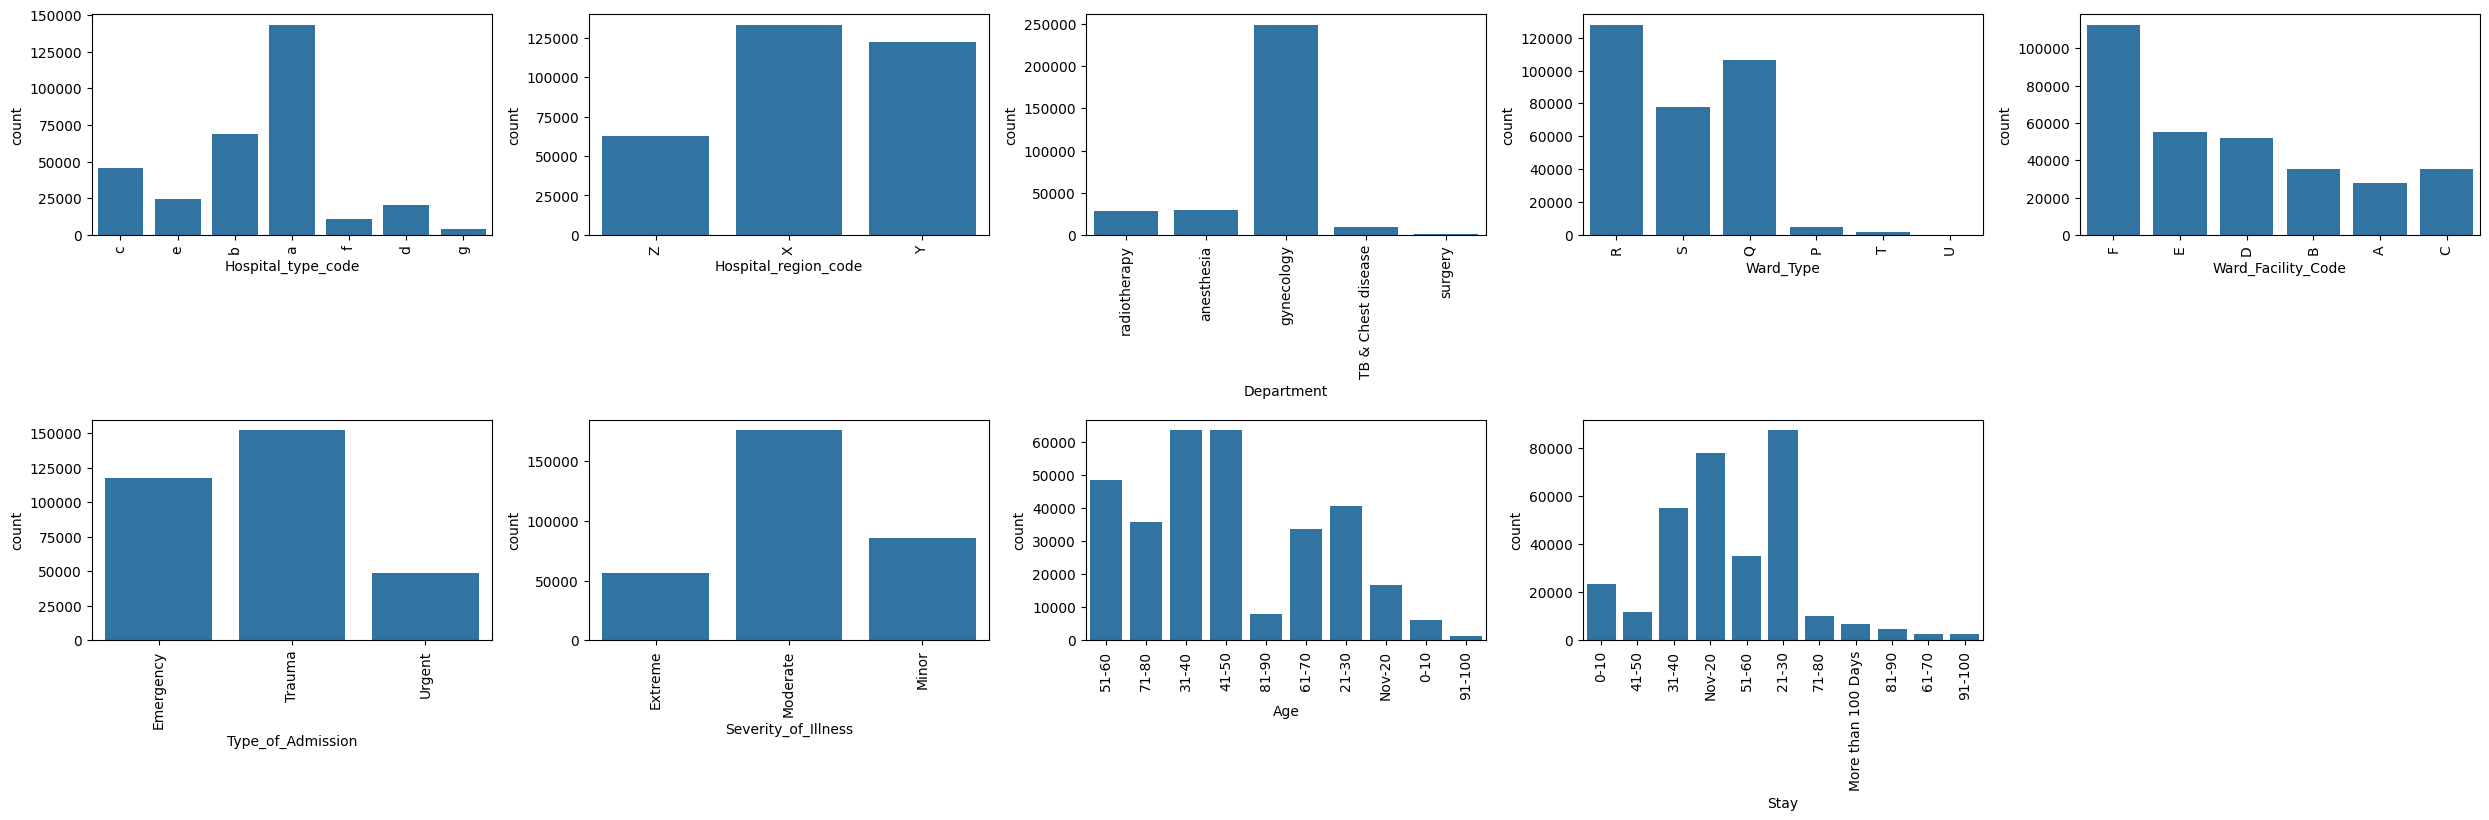

In [15]:
plot=1
plt.figure(figsize=(25,35))

for i in cat_cols:
  if plot <= len(cat_cols):
    plt.subplot(9,5,plot)
    sns.countplot(x=i, data=df)
    plt.xticks(rotation=90)
    plot += 1

plt.tight_layout()
plt.show()

### ***Insights:-***
- Visualizes categorical feature distribution while focusing on major categories for better clarity and interpretation.

# *******Bivariate Analysis*******

#### ****Numerical Columns:-**** Bivariate Analysis

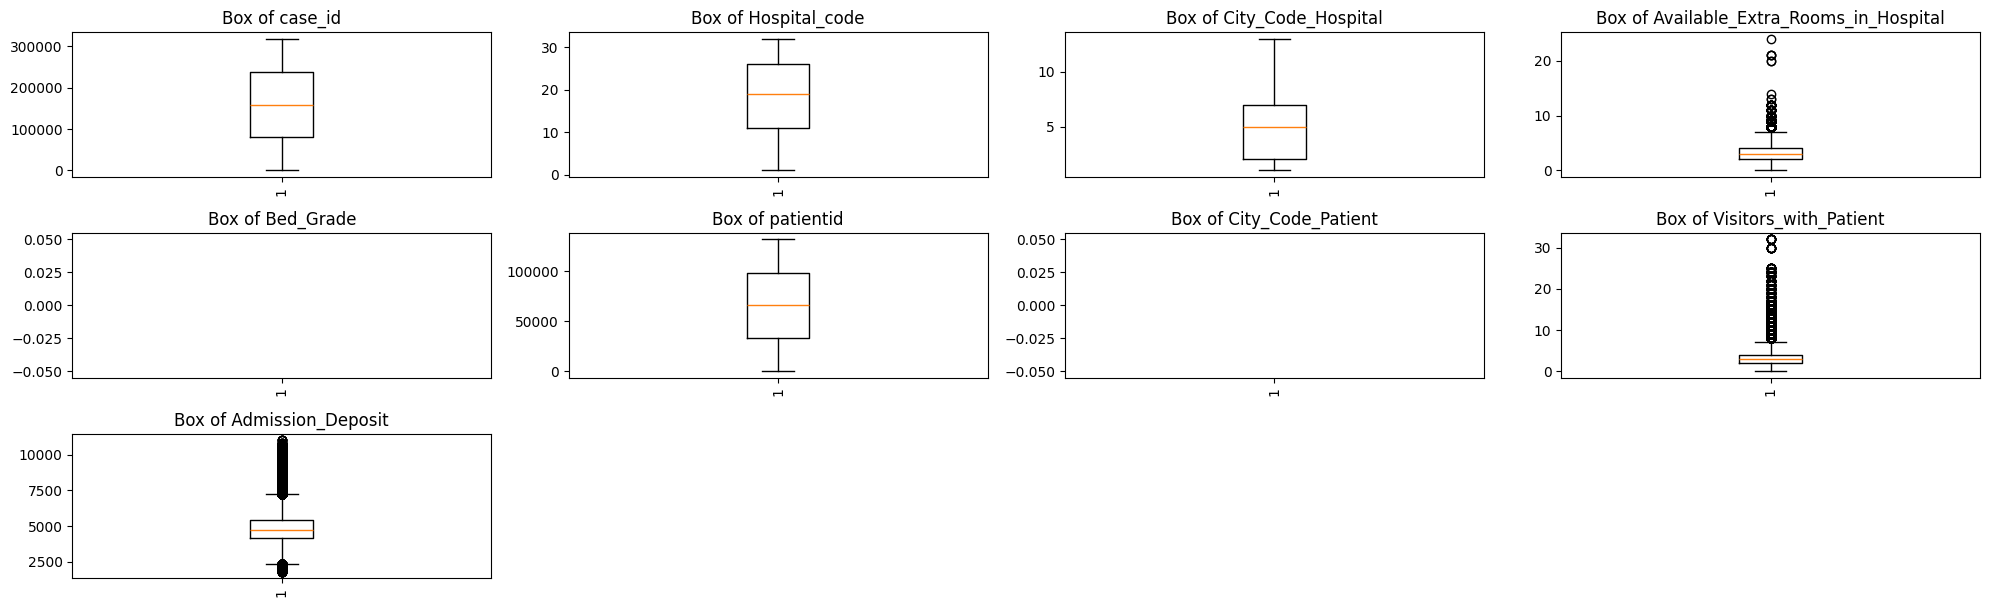

In [16]:
plt.figure(figsize=(20,10))
plot=1

for i in num_cols:
  if plot <= len(num_cols):
    plt.subplot(5,4,plot)
    plt.boxplot(x=i, data=df)
    plt.title(f"Box of {i}")
    plt.xticks(rotation=90)
    plot += 1

plt.tight_layout()
plt.show()


### ***Insights:-***
- Displays spread of numerical features using boxplots
- Helps identify outliers in each variable
- Shows median and quartile range (IQR) clearly
- Highlights skewness in data distribution
- Useful for detecting data variability and spread
- Helps decide outlier treatment (removal/capping)

#### ****Categorical Columns:-**** Bivariate Analysis

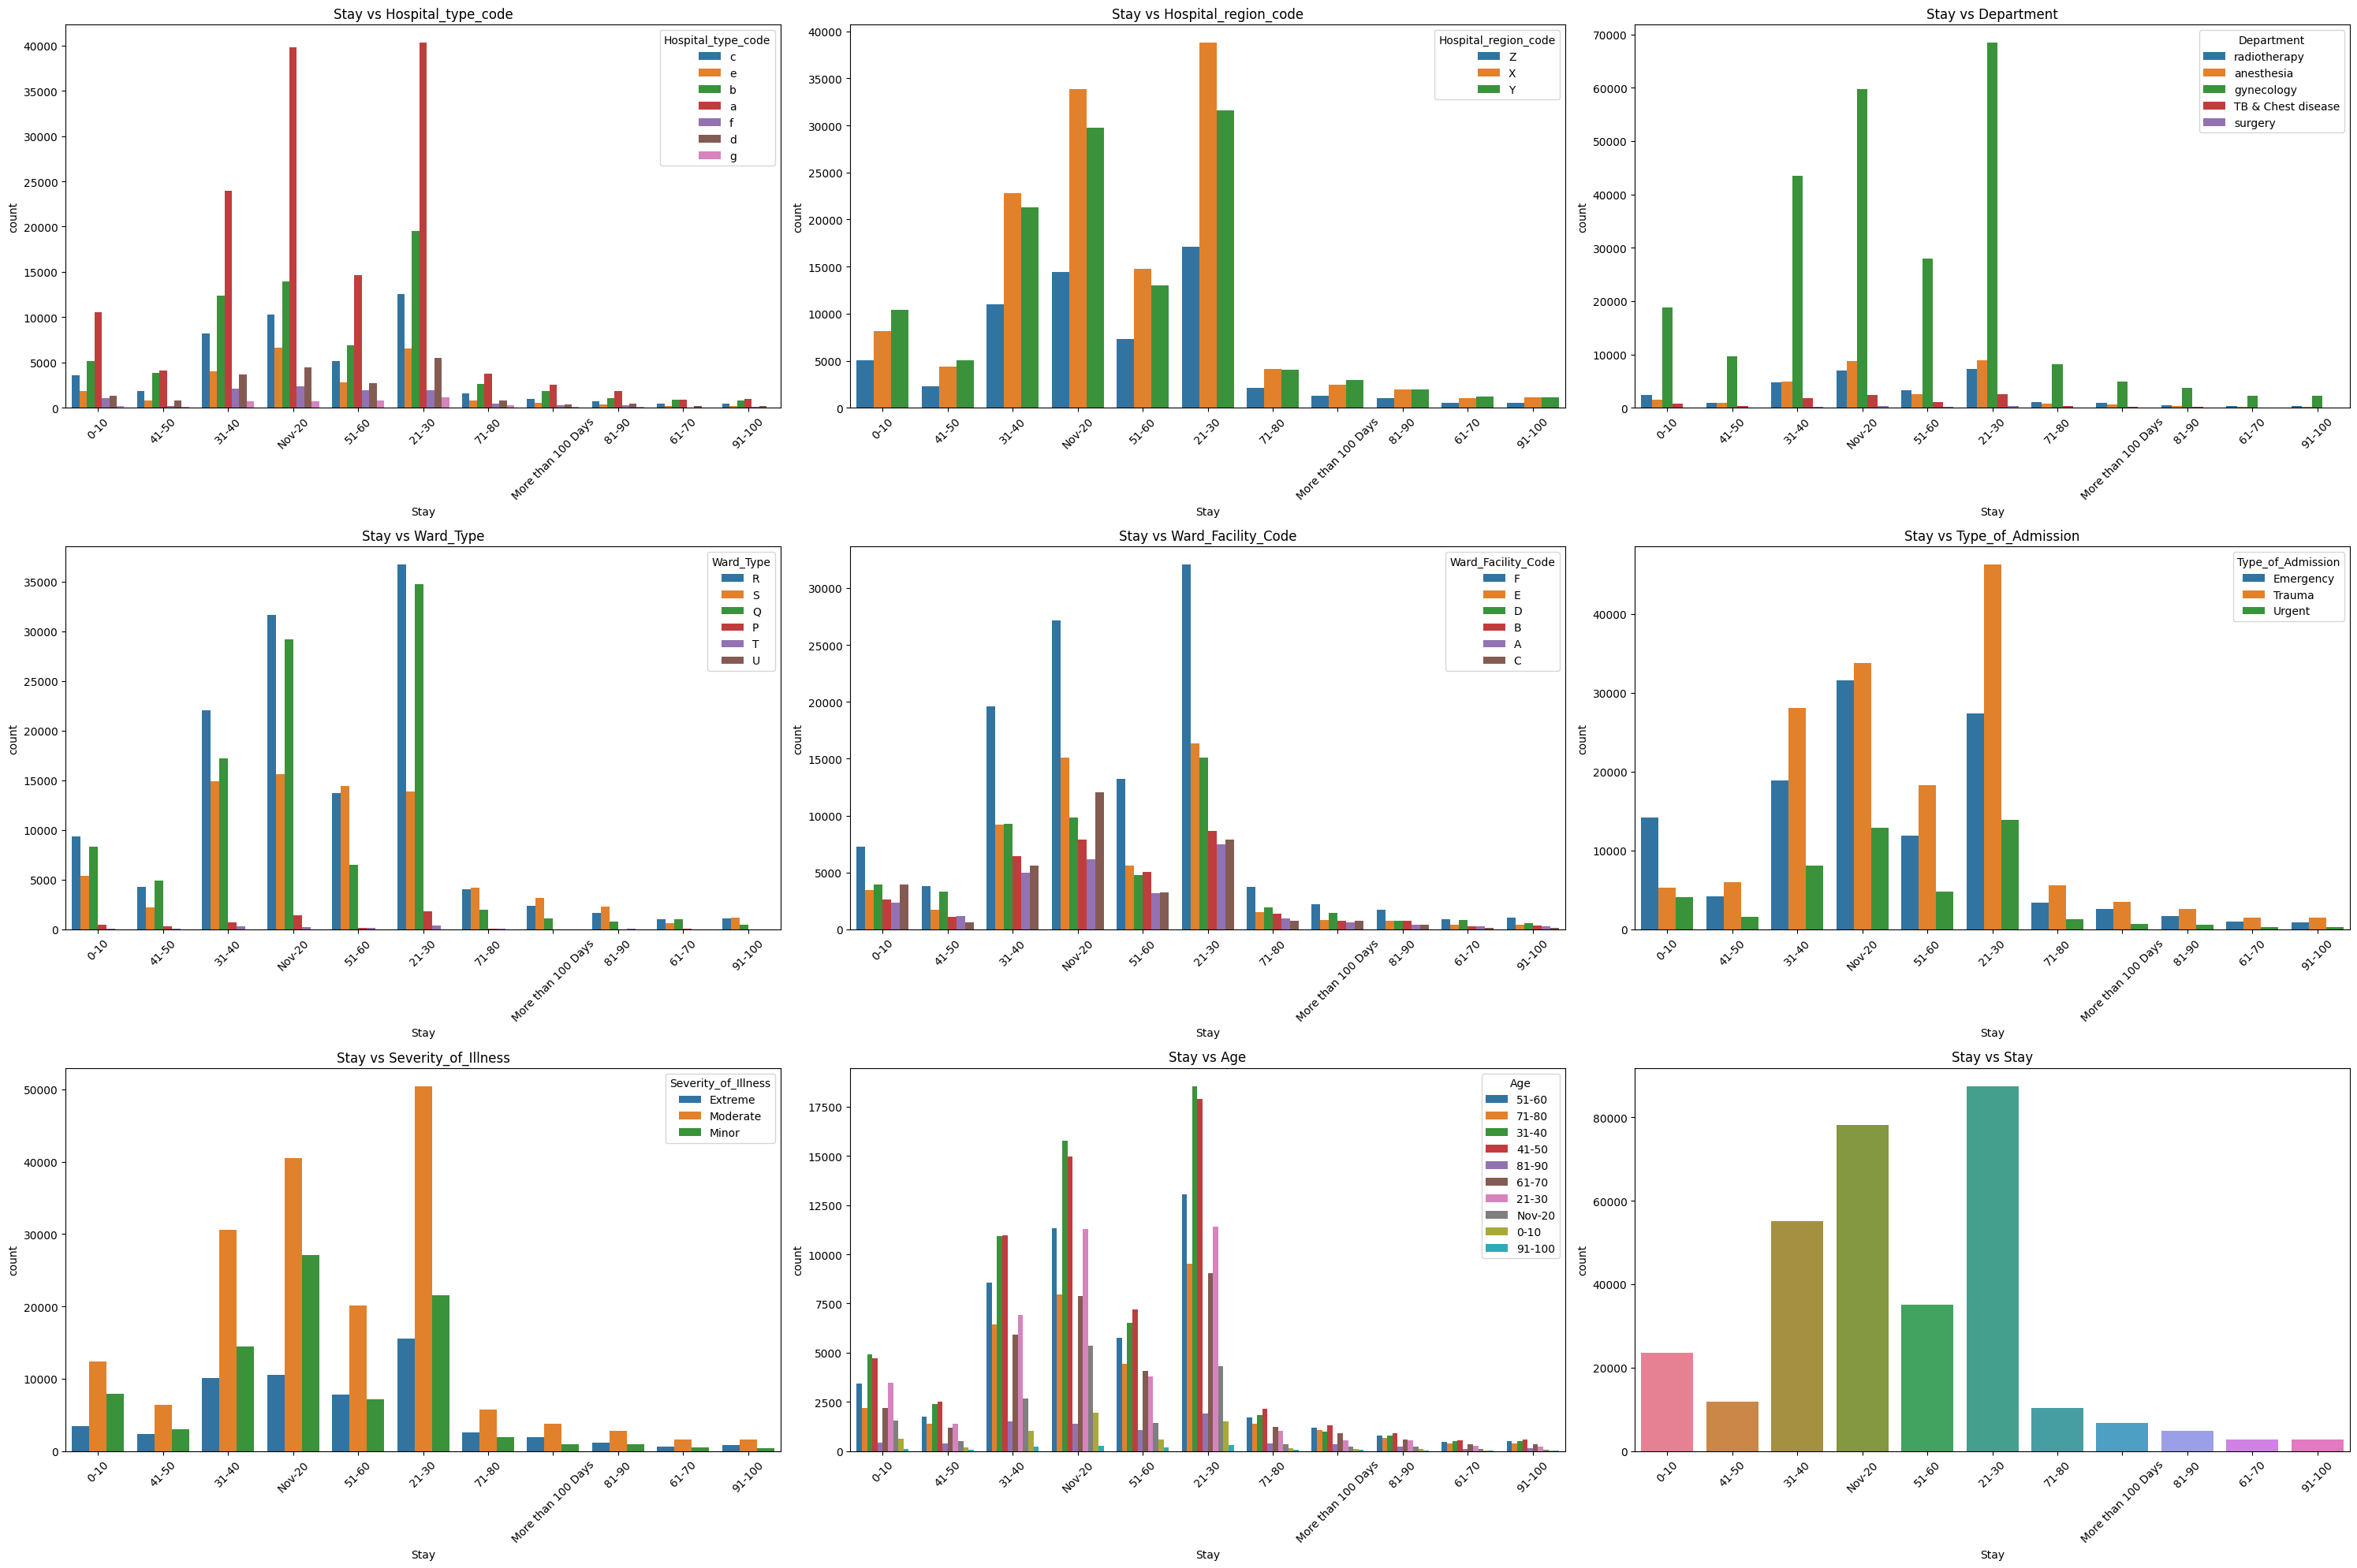

In [17]:
plt.figure(figsize=(30,20))
plot=1

for i in cat_cols:
  if plot <= len(cat_cols):
    plt.subplot(3,3,plot)
    sns.countplot(x='Stay', hue=i, data=df)
    plt.title(f"Stay vs {i}")
    plt.xticks(rotation=45)
    plot +=1

plt.tight_layout()
plt.show()

### ***Insights:-***
- Shows the relationship between categorical features and target variable, highlighting how different categories impact the average value.

# *******Multi-variate Analysis*******

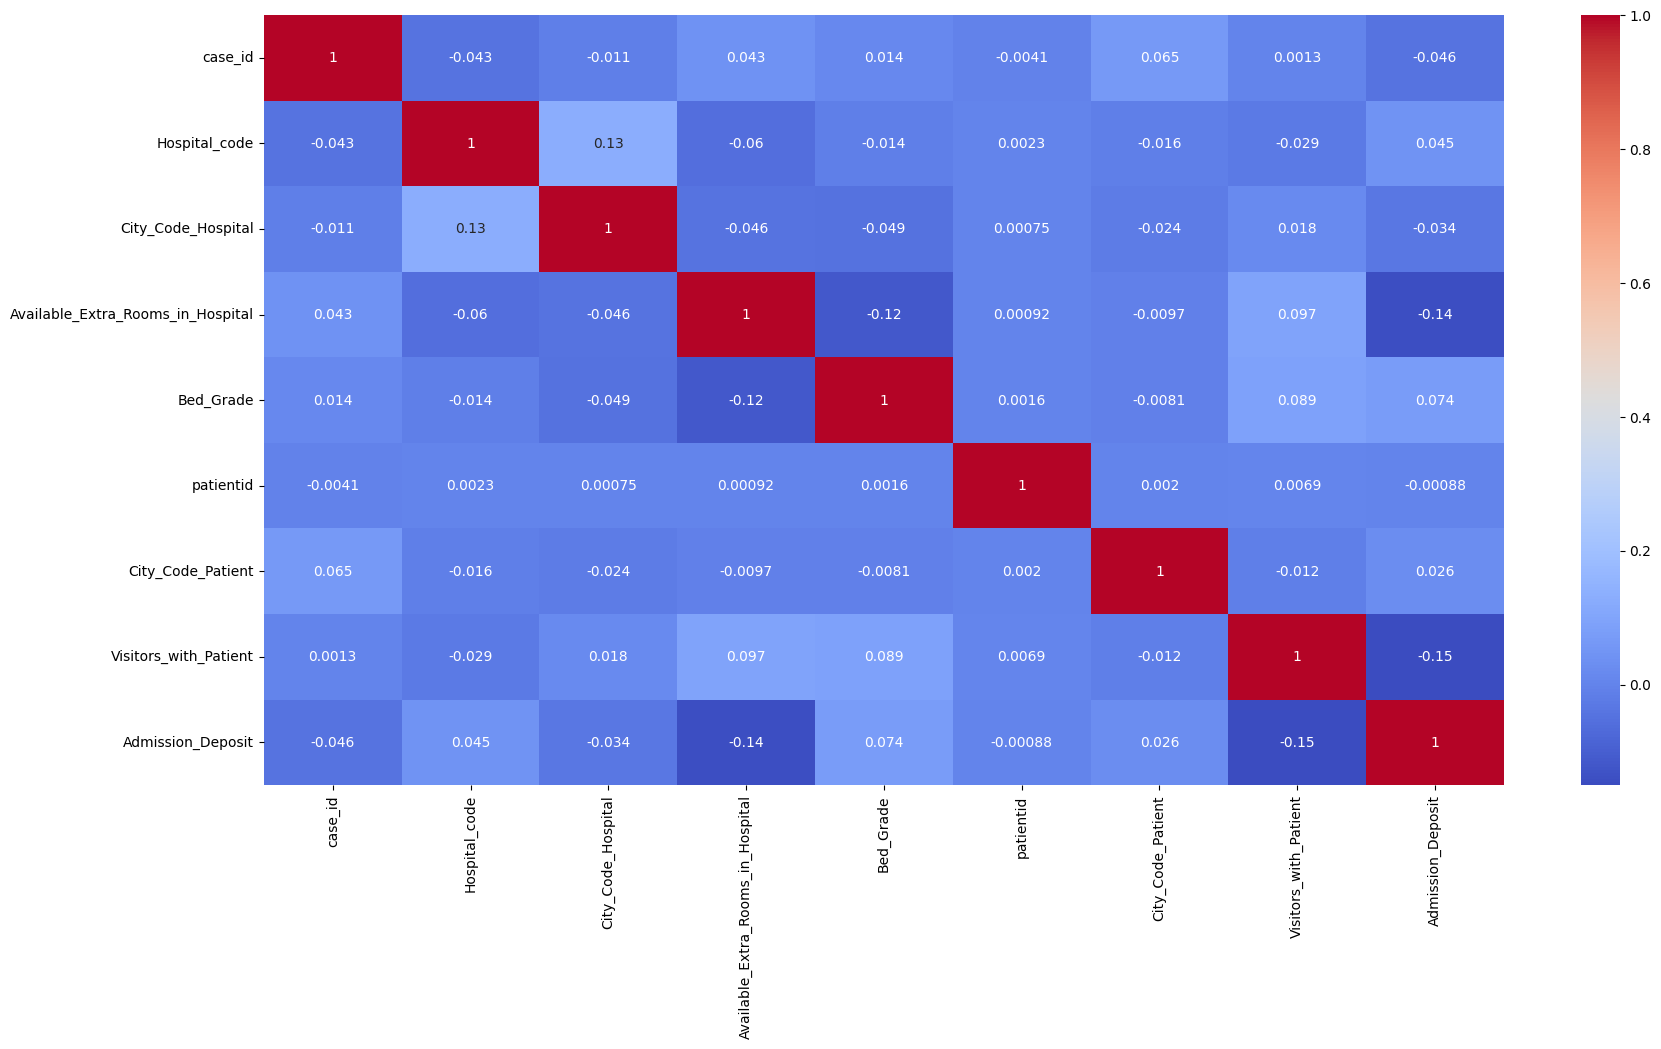

In [18]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

### ****Insights:-****
- Identifies strong positive/negative relationships between numerical features
Helps in feature selection and removing multicollinearity

#### ***Handling Missing Values:-***

In [19]:
df.isnull().sum()

,0
case_id,0
Hospital_code,0
Hospital_type_code,0
City_Code_Hospital,0
Hospital_region_code,0
Available_Extra_Rooms_in_Hospital,0
Department,0
Ward_Type,0
Ward_Facility_Code,0
Bed_Grade,113


##### **Insights:-**
- Median is used for numerical columns because it handles outliers better.
- Mode is used for categorical columns because categories cannot use mean/median.
- Missing value treatment improves model performance.
- Simple imputation avoids data loss from dropping rows.

In [20]:
# df['Bed_Grade'].fillna(df['Bed_Grade'].mode()[0], inplace=True)

In [21]:
df['Bed_Grade'].fillna(df['Bed_Grade'].median(), inplace=True)

### ****Insights:-****
1. Fill with mode because it is categorical/ordinal data.


In [22]:
df['City_Code_Patient'].fillna(
    df['City_Code_Patient'].median(),
    inplace=True
)

### ****Insights:-****
1. This is a numerical column but represent categories/code
2. fill with median.

### ****Checking duplicate Values:-****

In [23]:
df.duplicated().sum()

np.int64(0)

## *****Handling Outliers:-*****

#### ***IQR Method:-***

In [24]:
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  outliers = df[(df[col] < lower) | (df[col] > upper)]
  print(f"{col}: {outliers.shape[0]} outliers")

case_id: 0 outliers
Hospital_code: 0 outliers
City_Code_Hospital: 0 outliers
Available_Extra_Rooms_in_Hospital: 1351 outliers
Bed_Grade: 0 outliers
patientid: 0 outliers
City_Code_Patient: 24780 outliers
Visitors_with_Patient: 9804 outliers
Admission_Deposit: 12316 outliers


#### **Capping Outliers Method:-**

In [25]:
df_cap = df.copy()

for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR

  df_cap[col] = np.where(df_cap[col] < lower, lower, df_cap[col])
  df_cap[col] = np.where(df_cap[col] > upper, upper, df_cap[col])

### *****Insights:-*****
- Outliers were detected using IQR method
- Extreme values were either removed or capped
- Capping is preferred to retain data and reduce skewness
- Handling outliers improves model performance and stability

In [26]:
df.Age.value_counts()

,count
Age,
41-50,63749
31-40,63639
51-60,48514
21-30,40843
71-80,35792
61-70,33687
Nov-20,16768
81-90,7890
0-10,6254


# ******Encoding:-******
- Convert Categorical to Numerical

# ***Mapping:-***

In [27]:
df.Type_of_Admission.value_counts()

,count
Type_of_Admission,
Trauma,152261
Emergency,117676
Urgent,48501


In [28]:
stay_mapping = {
    '0-10': 0,
    '11-20': 1,
    'Nov-20': 1, # Added to map 'Nov-20' to 1
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9,
    'More than 100 Days': 10
}

df['Stay'] = df['Stay'].map(stay_mapping)

In [29]:
age_mapping = {
    '0-10': 0,
    '11-20': 1,
    'Nov-20': 1, # Added to map 'Nov-20' to 1
    '21-30': 2,
    '31-40': 3,
    '41-50': 4,
    '51-60': 5,
    '61-70': 6,
    '71-80': 7,
    '81-90': 8,
    '91-100': 9
}

df['Age'] = df['Age'].map(age_mapping)

In [30]:
severity_mapping = {
    'Minor': 0,
    'Moderate': 1,
    'Extreme': 2
}

df['Severity_of_Illness'] = df['Severity_of_Illness'].map(severity_mapping)

In [31]:
admission_mapping = {
    'Emergency': 0,
    'Trauma': 1,
    'Urgent': 2
}

df['Type_of_Admission'] = df['Type_of_Admission'].map(admission_mapping)

# ****OneHot Encoding:-****

In [32]:
# One-hot encoding
categorical_cols = [
    'Hospital_type_code',
    'Hospital_region_code',
    'Ward_Type',
    'Ward_Facility_Code',
    'Department',
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [33]:
df.head()

,case_id,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,patientid,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Hospital_region_code_Y,Hospital_region_code_Z,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery
0,1,8,3,3,2.0,31397,7.0,0,2,2,5,4911,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,2,2,5,2,2.0,31397,7.0,1,2,2,5,5954,4,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,3,10,1,2,2.0,31397,7.0,1,2,2,5,4745,3,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
3,4,26,2,2,2.0,31397,7.0,1,2,2,5,7272,4,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
4,5,26,2,2,2.0,31397,7.0,1,2,2,5,5558,4,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0


# Correlation of all columns with target column


In [34]:
corr_target = df.corr(numeric_only=True)['Stay'].sort_values(ascending=False)

print(corr_target)

Stay                                 1.000000
Visitors_with_Patient                0.537537
Ward_Type_S                          0.176936
Severity_of_Illness                  0.126160
Age                                  0.094163
Hospital_code                        0.042846
Hospital_type_code_b                 0.040093
Ward_Facility_Code_D                 0.037933
Hospital_type_code_g                 0.034605
Ward_Facility_Code_B                 0.032259
Hospital_type_code_f                 0.030880
Bed_Grade                            0.025761
Type_of_Admission                    0.023617
Hospital_type_code_d                 0.021421
Department_radiotherapy              0.017290
Department_surgery                   0.015537
Hospital_type_code_c                 0.013648
Ward_Facility_Code_F                 0.012300
Department_gynecology                0.010516
Ward_Type_T                          0.009119
Hospital_region_code_Z               0.007266
Hospital_region_code_Y            

##### **Insights:-**
- Calculates correlation of all numeric features with the target column Stay.
- numeric_only=True ignores non-numeric (string/object) columns.
- Helps identify which features are most strongly related to hospital stay prediction.
- Positive correlation → feature value increases as Stay increases.
- Negative correlation → feature value decreases as Stay increases.
- Features with correlation near 0 have weak or no linear relationship with Stay.
- Useful for feature selection and understanding important variables before model training.

# Drop case_id & patientid

In [35]:
df.drop(columns=['case_id', 'patientid'], inplace=True)

In [36]:
df.head()

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Hospital_region_code_Y,Hospital_region_code_Z,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery
0,8,3,3,2.0,7.0,0,2,2,5,4911,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,2,5,2,2.0,7.0,1,2,2,5,5954,4,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,10,1,2,2.0,7.0,1,2,2,5,4745,3,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
3,26,2,2,2.0,7.0,1,2,2,5,7272,4,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
4,26,2,2,2.0,7.0,1,2,2,5,5558,4,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 33 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Hospital_code                      318438 non-null  int64  
 1   City_Code_Hospital                 318438 non-null  int64  
 2   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 3   Bed_Grade                          318438 non-null  float64
 4   City_Code_Patient                  318438 non-null  float64
 5   Type_of_Admission                  318438 non-null  int64  
 6   Severity_of_Illness                318438 non-null  int64  
 7   Visitors_with_Patient              318438 non-null  int64  
 8   Age                                318438 non-null  int64  
 9   Admission_Deposit                  318438 non-null  int64  
 10  Stay                               318438 non-null  int64  
 11  Hospital_type_code_b               3184

# *********Scaling*********

In [38]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# df['Admission_Deposit'] = scaler.fit_transform(df[['Admission_Deposit']])

In [39]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df['Admission_Deposit'] = scaler.fit_transform(
    df[['Admission_Deposit']]
)

##### **Insights:-**
- MinMaxScaler scales Admission_Deposit values between 0 and 1, so no negative values are generated after transformation.
- It helps maintain the original distribution pattern of the data while reducing the impact of very large values.
- MinMax scaling is useful for distance-based algorithms like KNN and Neural Networks, but usually not required for tree-based models.

In [40]:
df.head()

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Stay,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Hospital_region_code_Y,Hospital_region_code_Z,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery
0,8,3,3,2.0,7.0,0,2,2,5,0.337858,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,2,5,2,2.0,7.0,1,2,2,5,0.451129,4,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,10,1,2,2.0,7.0,1,2,2,5,0.319831,3,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
3,26,2,2,2.0,7.0,1,2,2,5,0.594266,4,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
4,26,2,2,2.0,7.0,1,2,2,5,0.408123,4,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0


# ********Split the data:-********

##### ***(i) Split input & Output features:-***

In [41]:
X = df.drop('Stay', axis=1)

y = df['Stay']

In [42]:
X

,Hospital_code,City_Code_Hospital,Available_Extra_Rooms_in_Hospital,Bed_Grade,City_Code_Patient,Type_of_Admission,Severity_of_Illness,Visitors_with_Patient,Age,Admission_Deposit,Hospital_type_code_b,Hospital_type_code_c,Hospital_type_code_d,Hospital_type_code_e,Hospital_type_code_f,Hospital_type_code_g,Hospital_region_code_Y,Hospital_region_code_Z,Ward_Type_Q,Ward_Type_R,Ward_Type_S,Ward_Type_T,Ward_Type_U,Ward_Facility_Code_B,Ward_Facility_Code_C,Ward_Facility_Code_D,Ward_Facility_Code_E,Ward_Facility_Code_F,Department_anesthesia,Department_gynecology,Department_radiotherapy,Department_surgery
0,8,3,3,2.0,7.0,0,2,2,5,0.337858,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1,0
1,2,5,2,2.0,7.0,1,2,2,5,0.451129,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0
2,10,1,2,2.0,7.0,1,2,2,5,0.319831,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0
3,26,2,2,2.0,7.0,1,2,2,5,0.594266,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0
4,26,2,2,2.0,7.0,1,2,2,5,0.408123,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318433,6,6,3,4.0,23.0,0,1,3,4,0.254561,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0
318434,24,1,2,4.0,8.0,2,1,4,8,0.532037,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0
318435,7,4,3,4.0,10.0,0,0,3,7,0.264444,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0
318436,11,2,3,3.0,8.0,1,0,5,1,0.212967,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0


In [43]:
y

,Stay
0,0
1,4
2,3
3,4
4,4
...,...
318433,1
318434,3
318435,1
318436,1


##### ***(ii) Split the data into train & test:-***


In [44]:
X.shape

(318438, 32)

In [45]:
y.unique()

array([ 0,  4,  3,  1,  5,  2,  7, 10,  8,  6,  9])

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)



# ********Model Creation & Implimentation:-********


In [50]:
Log_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)
Log_model.fit(X_train, y_train)     # training the model

LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

In [51]:
y_pred_Log = Log_model.predict(X_test)

In [52]:
acc_s_Log = accuracy_score(y_test, y_pred_Log)
print(acc_s_Log)

0.24726793116442658


In [53]:
clf_r = classification_report(y_test, y_pred_Log)
print(clf_r)

              precision    recall  f1-score   support

           0       0.18      0.48      0.26      4721
           1       0.42      0.26      0.32     15628
           2       0.46      0.28      0.35     17498
           3       0.27      0.08      0.12     11032
           4       0.07      0.20      0.11      2349
           5       0.33      0.24      0.28      7004
           6       0.02      0.19      0.03       549
           7       0.11      0.06      0.08      2051
           8       0.12      0.32      0.18       967
           9       0.05      0.32      0.09       553
          10       0.33      0.49      0.39      1336

    accuracy                           0.25     63688
   macro avg       0.21      0.27      0.20     63688
weighted avg       0.34      0.25      0.26     63688



# Random Forest Classifier

In [54]:
RF_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
RF_model.fit(X_train, y_train)      # training the model

RandomForestClassifier(random_state=42)

In [55]:
y_pred_RF = RF_model.predict(X_test)

In [56]:
acc_s_RF = accuracy_score(y_test, y_pred_RF)
print(acc_s_RF)

0.3789410878030398


In [57]:
clf_r = classification_report(y_test, y_pred_RF)
print(clf_r)

              precision    recall  f1-score   support

           0       0.28      0.17      0.21      4721
           1       0.38      0.44      0.41     15628
           2       0.41      0.53      0.46     17498
           3       0.33      0.27      0.30     11032
           4       0.09      0.03      0.04      2349
           5       0.39      0.45      0.41      7004
           6       0.07      0.01      0.02       549
           7       0.26      0.10      0.14      2051
           8       0.39      0.21      0.27       967
           9       0.27      0.07      0.11       553
          10       0.55      0.45      0.49      1336

    accuracy                           0.38     63688
   macro avg       0.31      0.25      0.26     63688
weighted avg       0.36      0.38      0.36     63688



# Gradient Boosting

In [58]:
GB_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

GB_model.fit(X_train, y_train)   # training the model

GradientBoostingClassifier(random_state=42)

In [59]:
y_pred_GB = GB_model.predict(X_test)

In [60]:
acc_s_GB = accuracy_score(y_test, y_pred_GB)
print(acc_s_GB)

0.4108780303981912


In [61]:
clf_gb = classification_report(y_test, y_pred_GB)
print(clf_gb)

              precision    recall  f1-score   support

           0       0.38      0.11      0.18      4721
           1       0.42      0.49      0.45     15628
           2       0.42      0.66      0.51     17498
           3       0.40      0.17      0.24     11032
           4       0.38      0.00      0.00      2349
           5       0.38      0.53      0.44      7004
           6       0.25      0.00      0.00       549
           7       0.26      0.01      0.02      2051
           8       0.32      0.22      0.26       967
           9       0.19      0.01      0.02       553
          10       0.51      0.40      0.45      1336

    accuracy                           0.41     63688
   macro avg       0.35      0.24      0.23     63688
weighted avg       0.40      0.41      0.37     63688



# *****XGBoosting:-*****

In [62]:
XGB_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

XGB_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [63]:
y_pred_XGB = XGB_model.predict(X_test)

In [64]:
acc_s_XGB = accuracy_score(y_test, y_pred_XGB)
print(acc_s_XGB)

0.4214137671146841


In [65]:
clf_r = classification_report(y_test, y_pred_XGB)
print(clf_r)

              precision    recall  f1-score   support

           0       0.38      0.13      0.20      4721
           1       0.43      0.50      0.46     15628
           2       0.42      0.66      0.51     17498
           3       0.42      0.22      0.29     11032
           4       0.20      0.00      0.00      2349
           5       0.40      0.50      0.44      7004
           6       0.00      0.00      0.00       549
           7       0.43      0.02      0.04      2051
           8       0.39      0.22      0.28       967
           9       0.21      0.01      0.02       553
          10       0.54      0.41      0.47      1336

    accuracy                           0.42     63688
   macro avg       0.35      0.24      0.25     63688
weighted avg       0.41      0.42      0.38     63688



# ******Hyper parameter Tunning by all Algorithms:-******

# Tunning of XGBoosting:-

In [66]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV


xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=len(y.unique()),
    eval_metric='mlogloss'
)

params = {
    'n_estimators': [100,200,300],
    'max_depth': [3,5,7,10],
    'learning_rate': [0.01,0.05,0.1,0.2],
    'subsample': [0.7,0.8,1],
    'colsample_bytree': [0.7,0.8,1]
}

random_xgb = RandomizedSearchCV(
    xgb,
    params,
    n_iter=20,
    cv=5,
    scoring='f1_weighted',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

random_xgb.fit(X_train, y_train)

print(random_xgb.best_params_)
print(random_xgb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 0.8, 'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
0.3939472664191401


In [67]:
y_pred_RXGB = random_xgb.predict(X_test)

In [68]:
acc_s_RXGB = accuracy_score(y_test, y_pred_RXGB)
print(acc_s_RXGB)

0.426909307875895


In [69]:
preci_RXGB = precision_score(y_test, y_pred_RXGB, average='weighted')
print(preci_RXGB)

0.4073044826958531


In [70]:
Recall_RXGB = recall_score(y_test, y_pred_RXGB, average='weighted')
print(Recall_RXGB)

0.426909307875895


In [71]:
clf_r = classification_report(y_test, y_pred_RXGB)
print(clf_r)

              precision    recall  f1-score   support

           0       0.38      0.16      0.23      4721
           1       0.44      0.50      0.46     15628
           2       0.43      0.67      0.52     17498
           3       0.42      0.23      0.30     11032
           4       0.12      0.00      0.01      2349
           5       0.41      0.49      0.45      7004
           6       0.08      0.00      0.00       549
           7       0.33      0.05      0.09      2051
           8       0.38      0.22      0.28       967
           9       0.31      0.04      0.06       553
          10       0.57      0.43      0.49      1336

    accuracy                           0.43     63688
   macro avg       0.35      0.25      0.26     63688
weighted avg       0.41      0.43      0.39     63688



# **LightGBM:-**

In [72]:
import lightgbm as lgb

In [73]:
   lgb_model = lgb.LGBMClassifier(
        n_estimators      = 1500,
        learning_rate     = 0.03,
        num_leaves        = 127,
        max_depth         = 10,
        min_child_samples = 20,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        class_weight      = 'balanced',
        random_state      = 42,
        n_jobs            = -1,
        verbose           = -1,
    )

In [74]:
 lgb_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(100),
        ]
    )

[100]	valid_0's multi_logloss: 1.85387
[200]	valid_0's multi_logloss: 1.80505
[300]	valid_0's multi_logloss: 1.78255
[400]	valid_0's multi_logloss: 1.7663
[500]	valid_0's multi_logloss: 1.75305
[600]	valid_0's multi_logloss: 1.7409
[700]	valid_0's multi_logloss: 1.72963
[800]	valid_0's multi_logloss: 1.72025
[900]	valid_0's multi_logloss: 1.7122
[1000]	valid_0's multi_logloss: 1.70502
[1100]	valid_0's multi_logloss: 1.69864
[1200]	valid_0's multi_logloss: 1.69321
[1300]	valid_0's multi_logloss: 1.68864
[1400]	valid_0's multi_logloss: 1.68355
[1500]	valid_0's multi_logloss: 1.67939


LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.03, max_depth=10, n_estimators=1500, n_jobs=-1,
               num_leaves=127, random_state=42, reg_alpha=0.1, reg_lambda=1.0,
               subsample=0.8, verbose=-1)

In [75]:
y_pred_lgb = lgb_model.predict(X_test)

In [76]:
acc_lgb = accuracy_score(y_test, y_pred_lgb)


In [77]:
print(f"\n[RESULT] Accuracy: {acc_lgb*100:.2f}%")


[RESULT] Accuracy: 34.25%


In [78]:
clf_r_lgb = classification_report(y_test, y_pred_lgb)
print(clf_r_lgb)

              precision    recall  f1-score   support

           0       0.24      0.50      0.32      4721
           1       0.45      0.37      0.41     15628
           2       0.47      0.40      0.43     17498
           3       0.39      0.15      0.22     11032
           4       0.09      0.24      0.13      2349
           5       0.38      0.37      0.38      7004
           6       0.02      0.05      0.03       549
           7       0.17      0.28      0.21      2051
           8       0.26      0.45      0.33       967
           9       0.09      0.11      0.10       553
          10       0.43      0.47      0.45      1336

    accuracy                           0.34     63688
   macro avg       0.27      0.31      0.28     63688
weighted avg       0.39      0.34      0.35     63688



# **CatBoost:-**

In [79]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [80]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier

cb = CatBoostClassifier(verbose=0)

param_grid = {
    'iterations': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8, 10],
    'l2_leaf_reg': [1, 3, 5, 7, 9],
    'border_count': [32, 50, 100],
    'bagging_temperature': [0, 1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=cb,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=CatBoostClassifier(verbose=0), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 1, 3, 5],
                                        'border_count': [32, 50, 100],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [100, 200, 300],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.05, 0.1]},
                   random_state=42, verbose=2)

In [81]:
from catboost import CatBoostClassifier

cb = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cb.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

In [82]:
best_model = random_search.best_estimator_

In [83]:
y_pred_cb = best_model.predict(X_test)

In [84]:
acc_s_cb = accuracy_score(y_test, y_pred_cb)
print(acc_s_cb)

0.42292111543775907


# ROC CURVE (MULTI-CLASS)


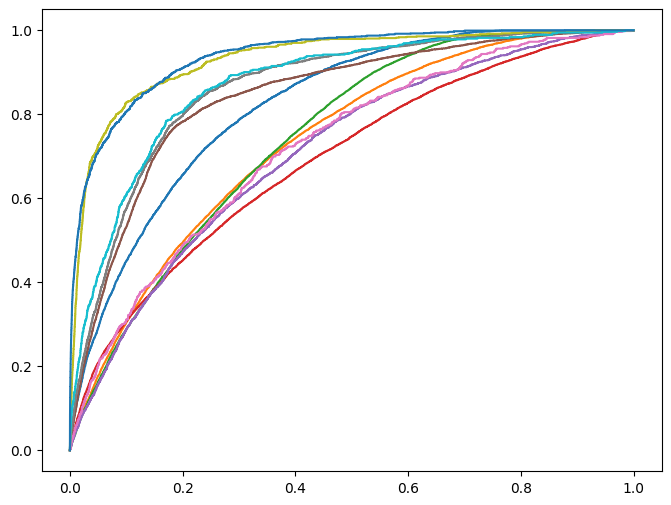

In [99]:
    plt.figure(figsize=(8,6))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(
            y_test_bin[:, i],
            y_prob[:, i]
        )

        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"Class {classes[i]} (AUC = {roc_auc:.2f})"
        )

# Random line


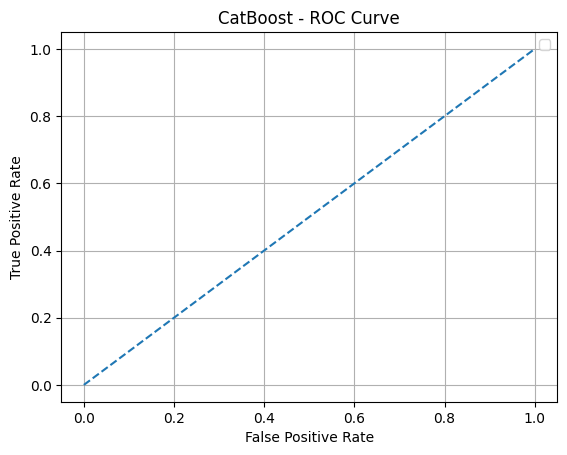

In [100]:
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title(f"{name} - ROC Curve")

    plt.legend()
    plt.grid(True)

    plt.show()


# **********Hospital Stay Prediction********** -  *******Machine Learning Project Report*******

##### ****---Length of Patient Stay Prediction using Classification Models---****

######    Total Records =   318,438

######      Features    =   18

######     ML Models    =   4

######   Best Accuracy  = 42.29%

### ****1. Project Overview:-****
- This project predicts the length of hospital stay
- for patients using supervised machine learning classification.
- Accurate prediction helps hospitals plan bed allocation, staffing, and resources more efficiently
- reducing costs and improving patient care.

### **Goal** : Classify patient stay duration into 11 categories (0-10 days to More than 100 days) using patient demographics, admission type, illness severity, and hospital characteristics.

## *****Business Problem:-*****
- Hospitals face operational challenges when patient stay duration is unpredictable.

 The consequences include:

•Poor bed and ward management

•Increased operational costs and resource wastage

•Delayed patient admissions and bottlenecks

•Reduced healthcare efficiency and staff overload

### ****2. Dataset Overview:-****

######  Total Rows = 318,438

######  Total Columns = 18

######  Numerical Features = 9

###### Categorical Features = 9

###### Target Classes = 11

## *Feature Summary:-*

| Feature Name                      |Type               | Description                               |
| --------------------------------- |-------------------|-----------------------------------------  |
| case_id / patienid                | ID(dropped)       | Unique patient case identifier            |
| Hospital_code                     | Numerical         | Unique hospital identifier                |
| Hospital_type_code                | Categorical       | Type/category of hospital                 |
| Hospital_region_code              | Categorical       | Hospital region information               |
| Available Extra Rooms in Hospital | Numerical         | Number of extra rooms available           |
| Department                        | categorical       | Department where patient admitted         |
| Ward_Type                         | Categorical       | Ward category                             |
| Ward_Facility_Code                | Categorical       | Ward facility information                 |
| Bed Grade                         | Numerical         | Quality/category of hospital bed          |
| City_Code_Hospital                | Numerical         | Hospital city code                        |
| Type_of_Admission                 | Categorical       | Admission type                            |
| Severity of Illness               | Categorical       | Severity level of patient illness         |
| Visitors with Patient             | Numerical         | Number of visitors                        |
| Age                               | Categorical       | Age group of patient                      |
| Admission_Deposit                 | Numerical         | Deposit amount paid                       |
| City_Code_Patient                 | Numerical         | Patient city code                         |
| Stay                              | Categorical       | Target column representing length of stay |


## *Target Variable — Stay Classes:-*
- The target variable has 11 ordinal categories encoded as integers 0-10:


| Class              |   Stay Duration     |   Encoded Value  |
| -------------------|---------------------|------------------|
| Class 0            |   0-10 Days         |        0         |
| Class 1            |   11-20  Days       |        1         |
| Class 2            |   21-30  Days       |        2         |
| Class 3            |   31-40  Days       |        3         |
| Class 4            |   41-50  Days       |        4         |  
| Class 5            |   51-60  Days       |        5         |
| Class 6            |   61-70  Days       |        6         |
| Class 7            |   71-80   Days      |        7         |
| Class 8            |   81-90   Days      |        8         |
| Class 9            |   91-100   Days     |        9         |
| Class 10           |   More than 100 Days|        10        |


##  ***3. Data Preprocessing:-***




#### Missing Value Treatment:-

|      Column                        |   Strategy           |         Reason                                |
| -----------------------------------|----------------------|-----------------------------------------------|
|     Bed_Grade                      | Median Imputation    | Numerical/ordinal; median is outlier-robust   |
|    City_Code_Patient               | Median Imputation    | Numeric code; median preferred over mean      |



####  Outlier Handling
Outliers were detected using the IQR method on all numerical columns.

Capping (Winsorization) was applied to retain data while reducing skewness:

•Lower cap: Q1 - 1.5 x IQR

•Upper cap: Q3 + 1.5 x IQR

•Capping preferred over removal to preserve dataset size

##  **Encoding Strategy:-**


|      Feature                                      |     Encoding               |      Reason                             |
|---------------------------------------------------|----------------------------|-----------------------------------------|
|     Stay (target)                                 | Ordinal Mapping (0-10)     | Ordered categories                      |
|     Age                                           | Ordinal Mapping (0-9)      | Ordered age groups                      |
|   Severity_of_Illness                             | Ordinal Mapping            | Minor=0, Moderate=1, Extreme=2          |
|   Type_of_Admission                               | Ordinal Mapping            | Emergency=0, Trauma=1, Urgent=2         |
|   Hospital_type_code, Ward_Type, Department, etc. | One-Hot Encoding           | One-Hot Encoding                        |

## **Feature Scaling:-**
- MinMaxScaler applied to Admission_Deposit to normalize its range to [0, 1], avoiding bias in distance-sensitive models.

## **Train-Test Split:-**

##### *Split Configuration:-*
|  80% Training / 20% Testing  |

|  random_state=42  |

|  Stratified on target class to preserve class distribution |

## **4. Exploratory Data Analysis (EDA)**

#### *Univariate Analysis:-*
•Numerical features:- 
                  Histograms with KDE revealed skewness in Admission_Deposit and Available_Extra_Rooms

•Categorical features:-
                 Count plots showed imbalanced hospital types and dominant ward categories


####  *Bivariate Analysis:-*
•Box plots showed spread of numerical features vs. hospital stay

•Severity of illness has a strong positive relationship with longer stays

•Emergency admissions correlated with longer hospitalization

•Certain departments (Surgery, Gynecology) showed higher average stays


#### *Multivariate Analysis — Correlation Heatmap:-*

•Low multicollinearity among numerical features

•Admission_Deposit showed moderate correlation with Stay

•Severity_of_Illness and Type_of_Admission were most influential features


##  **Key Domain Insights:-**

|                Factor             |                Impact on Stay                               |
|-----------------------------------|-------------------------------------------------------------|
|      Severity_of_Illness          |       Higher severity = significantly longer stay           |
|      Type_of_Admission            |      Emergency admissions tend to stay longer               |
|      Patient Age                  |      Elderly patients require longer hospitalization        |
|      Bed_Grade                    |      Higher-grade beds indicate more complex treatments     |
|      Admission_Deposit            |      Higher deposits indicate critical care episodes        |
|      Visitor_Count                |      Indirectly reflects patient condition severity         |

## **5. Machine Learning Models:-**

#### *Models Implemented:-*

|          Model                |       Type              |      Key Strength                            |
|-------------------------------|-------------------------|----------------------------------------------|
|       Logistic Regression     | Linear Classifier       | Fast baseline, easy interpretation           |
|       Random Forest           | Ensemble(Bagging)       | Handles non-linearity, reduces overfitting   |
|       XGBoost                 | Ensemble(Boosting)      | High performance on tabular data             |
|       CatBoost                | Ensemble(Boosting)      | Native categorical handling, best accuracy   |


##  **6. Model Performance:-**

|       Model             |   Accuracy      |   Log Loss       |   Verdict      |
| ------------------------|-----------------|------------------|----------------|
|    Logistic Regression  |   ~25%          |      N/A         |    Baseline    |
|    Random Forest        |   ~38%          |      N/A         |    Improved    |
|    XGBoost              |   ~41%          |      N/A         |    Strong      |
|    **CatBoost**         |  **42.29%**     |     1.5089       |  **Best Model**|


### ****Best Model:-****
**CatBoost: Accuracy: 42.29%**  
|  Log Loss: 1.5089  |  
|  Handles categorical features natively without extra encoding  |

## **Evaluation Metrics Used:-**

|             Metric             |             Purpose                                         |
|--------------------------------|-------------------------------------------------------------|
|           Accuracy             |   Overall prediction correctness across all 11 classes      |
|           Precision            |   Correctness of positive class predictions                 |
|           Recall               |   Ability to identify actual class instances                |
|           f1-score             |   Harmonic balance of Precision and Recall                  |
|           Log Loss             |   Probability-based error — lower is better                 |

##  **7. Key Findings & Challenges:-**

#### *Key Findings:-*

•Ensemble models significantly outperformed Logistic Regression baseline

•**CatBoost** handled **high-cardinality** categorical data most effectively

•Severity of illness and admission type were the most predictive features

•Class imbalance impacted minority class predictions (short and extreme stays)

•Feature engineering (ordinal mapping) improved model learning

#### *Challenges:-*

•11-class **multiclass** classification is inherently harder than binary prediction

•Class imbalance in target variable reduces minority class recall

•High **cardinality** in categorical features inflated one-hot encoded dimensions

•Accuracy capped around 42% — room for improvement with advanced techniques


## **8. Future Improvements:-**

|            Area                   |                Recommendation                               |
|-----------------------------------|-------------------------------------------------------------|
|      Class Imbalance              |     Apply SMOTE or class-weight balancing techniques        |
|      Feature Engineering          |     Create interaction features (Age x Severity, etc.)      |
|      Hyperparameter Tuning        |     GridSearchCV / Optuna for deeper model optimization     |
|      Advanced Models              |     Try **LightGBM**, Deep Neural Networks, or **TabNet**   |
|      Deployment                   |     Build REST API using Flask or Streamlit dashboard       |
|      Data Pipelines               |     Integrate real-time hospital admission data streams     |

## ****9. Real-World Impact:-****
- Deploying this predictive model in hospitals can deliver measurable operational and patient care improvements:


**Better**       =  Bed Utilization

**Lower**        =  Wait Times

**Reduced**      =  Op. Costs

**Data-driven**  =  Planning 

## **10. Technology Stack:-**

|            Category               |                Tools & Libraries                   |
|-----------------------------------|----------------------------------------------------|
|           Language                |     Python 3                                       |
|           Data Analysis           |     Numpy, Pandas                                  |
|           Visualization           |     Matplotlib, Seaborn                            |
|           Machine Learning        |     Scikit-learn, XGBoost, CatBoost                |
|         **Preprocessing**         |     LabelEncoder, OneHotEncoder, MinMaxScaler      |
|           Environment             |     Google Colab / Jupyter Notebook                |

##  ****11. Conclusion:-****
- This project successfully applied machine learning to the healthcare problem of predicting patient length of stay.
-  Four classification algorithms were trained and evaluated on 318,438 patient records.

**Final Verdict**:
- CatBoost delivered the best performance (42.29% accuracy)
due to its native handling of categorical features and boosting architecture. 
- The project demonstrates that predictive analytics can meaningfully support hospital resource planning and operational efficiency.

While accuracy could be further improved with SMOTE balancing, deeper feature engineering,
and **hyperparameter** tuning, this project serves as a solid foundation for healthcare predictive **analytics**.